In [1]:
import os
import cv2
import glob
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     Conv2DTranspose, concatenate, 
                                     BatchNormalization, Activation, add,
                                     MultiHeadAttention, LayerNormalization, Dense, Reshape)
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split

# ============================================================================
# 1. CẤU HÌNH HỆ THỐNG & LOCK SEED
# ============================================================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

SEED_VALUE = 24
def set_global_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_global_seed(SEED_VALUE)
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(f"Global Seed is strictly locked to: {SEED_VALUE}")

IMG_HEIGHT = 256  
IMG_WIDTH = 256   
N_CHANNELS = 1         # Ảnh huỳnh quang ISBI-2009 (Grayscale)
BATCH_SIZE = 8         
EPOCHS = 150           # Ép chạy đúng 150 Epochs theo bài báo gốc
LEARNING_RATE = 1e-3   
ALPHA = 1.67

2026-06-19 07:49:26.354800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781855366.512589      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781855366.562338      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781855366.920994      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781855366.921037      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781855366.921039      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Num GPUs Available: 1
Global Seed is strictly locked to: 24


In [2]:
base_path = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI2009"
img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

def load_isbi2009_data():
    X, Y = [], []
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    
    if len(img_files) == 0:
        raise ValueError("Không tìm thấy dữ liệu ảnh. Đang tự động chuyển sang chế độ sinh dữ liệu giả lập...")
        
    print(f"\nĐang nạp {len(img_files)} ảnh từ hệ thống ISBI-2009...")
    for f in tqdm(img_files, desc="Loading Dataset"):
        filename = os.path.basename(f)
        m_path = os.path.join(mask_dir, filename)
        if os.path.exists(m_path):
            img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            X.append(img)
            
            msk = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
            msk = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            Y.append(np.round(msk, 0))
            
    return np.expand_dims(np.array(X), -1), np.expand_dims(np.array(Y), -1)

try:
    X, Y = load_isbi2009_data()
    print(f"Thành công! X shape: {X.shape}, Y shape: {Y.shape}")
except Exception as e:
    print(f"Thông báo: {e}")
    X = np.random.rand(40, IMG_HEIGHT, IMG_WIDTH, 1).astype(np.float32)
    Y = np.random.randint(0, 2, (40, IMG_HEIGHT, IMG_WIDTH, 1)).astype(np.float32)
    print(f"Đã tạo dữ liệu ngẫu nhiên thay thế: X shape: {X.shape}")

# Phân chia tập dữ liệu nhanh bằng Train-Test Split (80% Train, 20% Validation)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=SEED_VALUE)
print(f"Split hoàn tất! Tập Train: {X_train.shape[0]} ảnh | Tập Val: {X_val.shape[0]} ảnh")


Đang nạp 97 ảnh từ hệ thống ISBI-2009...


Loading Dataset: 100%|██████████| 97/97 [00:02<00:00, 35.03it/s]


Thành công! X shape: (97, 256, 256, 1), Y shape: (97, 256, 256, 1)
Split hoàn tất! Tập Train: 77 ảnh | Tập Val: 20 ảnh


In [3]:
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu'):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    if activation is not None:
        x = Activation(activation)(x)
    return x

In [4]:
def MultiResBlock_base(U, inp): 
    W = ALPHA * U
    short = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
    c3 = conv2d_bn(inp, int(W*0.167), 3, 3)
    c5 = conv2d_bn(c3, int(W*0.333), 3, 3)
    c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
    return Activation('relu')(add([short, concatenate([c3, c5, c7], 3)]))

def ResPath_base(f, length, inp): 
    out = conv2d_bn(inp, f, 3, 3)
    out = add([conv2d_bn(inp, f, 1, 1, activation=None), out])
    out = Activation('relu')(BatchNormalization(axis=3)(out))
    for _ in range(length - 1):
        short = conv2d_bn(out, f, 1, 1, activation=None)
        out = conv2d_bn(out, f, 3, 3)
        out = Activation('relu')(add([short, out]))
        out = BatchNormalization(axis=3)(out)
    return out

def TransformerBlock(inputs, num_heads=4, embed_dim=128, ff_dim=512):
    shape = K.int_shape(inputs)
    h, w, c = shape[1], shape[2], shape[3]
    x = Reshape((h * w, c))(inputs)
    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = LayerNormalization(epsilon=1e-6)(add([x, attn_out]))
    ffn_out = Dense(c)(Dense(ff_dim, activation='relu')(x))
    return Reshape((h, w, c))(LayerNormalization(epsilon=1e-6)(add([x, ffn_out])))

In [5]:
# --- MODEL 1: BASELINE MULTIRES-UNET GỐC ---
def build_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    inputs = Input((height, width, n_channels))
    m1 = MultiResBlock_base(32, inputs); p1 = MaxPooling2D((2,2))(m1); r1 = ResPath_base(32, 4, m1)
    m2 = MultiResBlock_base(64, p1); p2 = MaxPooling2D((2,2))(m2); r2 = ResPath_base(64, 3, m2)
    m3 = MultiResBlock_base(128, p2); p3 = MaxPooling2D((2,2))(m3); r3 = ResPath_base(128, 2, m3)
    m4 = MultiResBlock_base(256, p3); p4 = MaxPooling2D((2,2))(m4); r4 = ResPath_base(256, 1, m4)
    m5 = MultiResBlock_base(512, p4)
    
    u6 = concatenate([Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(m5), r4], 3); m6 = MultiResBlock_base(256, u6)
    u7 = concatenate([Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_base(128, u7)
    u8 = concatenate([Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_base(64, u8)
    u9 = concatenate([Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_base(32, u9)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(m9), name='Baseline_MultiResUNet')

# --- MODEL 2: MULTIRESUNET + TRANSFORMER BOTTLENECK ---
def build_multiresunet_transformer(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    inputs = Input((height, width, n_channels))
    m1 = MultiResBlock_base(32, inputs); p1 = MaxPooling2D((2,2))(m1); r1 = ResPath_base(32, 4, m1)
    m2 = MultiResBlock_base(64, p1); p2 = MaxPooling2D((2,2))(m2); r2 = ResPath_base(64, 3, m2)
    m3 = MultiResBlock_base(128, p2); p3 = MaxPooling2D((2,2))(m3); r3 = ResPath_base(128, 2, m3)
    m4 = MultiResBlock_base(256, p3); p4 = MaxPooling2D((2,2))(m4); r4 = ResPath_base(256, 1, m4)
    
    m5 = MultiResBlock_base(512, p4)
    trans_bottleneck = TransformerBlock(m5, num_heads=4, embed_dim=128, ff_dim=512)
    
    u6 = concatenate([Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(trans_bottleneck), r4], 3); m6 = MultiResBlock_base(256, u6)
    u7 = concatenate([Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_base(128, u7)
    u8 = concatenate([Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_base(64, u8)
    u9 = concatenate([Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_base(32, u9)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(m9), name='MultiResUNet_Transformer')

In [6]:
print("\n" + "="*60)
print("  BẮT ĐẦU ABLATION STUDY SỬ DỤNG BINARY CROSSENTROPY LOSS")
print("  So sánh: MultiResUNet vs MultiResUNet + Transformer Bottleneck")
print("="*60)

os.makedirs('checkpoint_ablation', exist_ok=True)

# --- 5.1 Huấn luyện Model 1 ---
print(f"\n[Bước 1/2] Đang huấn luyện Model 1: Baseline MultiResUNet (Loss: BCE | {EPOCHS} epochs)...")
K.clear_session()
model_1 = build_multiresunet()
model_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy', metrics=[jacard, dice_coef])

chkpt_m1 = ModelCheckpoint('checkpoint_ablation/model1_base.weights.h5', monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)
history_m1 = model_1.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_m1], verbose=1)

m1_best_jaccard = max(history_m1.history['val_jacard'])
m1_best_dice = max(history_m1.history['val_dice_coef'])

# --- 5.2 Huấn luyện Model 2 ---
print(f"\n[Bước 2/2] Đang huấn luyện Model 2: MultiResUNet + Transformer (Loss: BCE | {EPOCHS} epochs)...")
K.clear_session()
model_2 = build_multiresunet_transformer()
model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy', metrics=[jacard, dice_coef])

chkpt_m2 = ModelCheckpoint('checkpoint_ablation/model2_trans.weights.h5', monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)
history_m2 = model_2.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_m2], verbose=1)

m2_best_jaccard = max(history_m2.history['val_jacard'])
m2_best_dice = max(history_m2.history['val_dice_coef'])

print("\n" + "✔️ QUY TRÌNH HUẤN LUYỆN TOÀN DIỆN ĐÃ HOÀN THÀNH THÀNH CÔNG!")


  BẮT ĐẦU ABLATION STUDY SỬ DỤNG BINARY CROSSENTROPY LOSS
  So sánh: MultiResUNet vs MultiResUNet + Transformer Bottleneck

[Bước 1/2] Đang huấn luyện Model 1: Baseline MultiResUNet (Loss: BCE | 150 epochs)...


I0000 00:00:1781855392.978000      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/150


2026-06-19 07:49:55.117491: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1781855422.000144     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
W0000 00:00:1781855423.742491     126 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 8
in_depths: 256
out_depths: 853
in: 32
in

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - dice_coef: 0.4290 - jacard: 0.2886 - loss: 0.4518

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 857ms/step - dice_coef: 0.4559 - jacard: 0.3128 - loss: 0.4281 - val_dice_coef: 0.2748 - val_jacard: 0.1596 - val_loss: 0.5948
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - dice_coef: 0.7920 - jacard: 0.6571 - loss: 0.1430 - val_dice_coef: 0.2539 - val_jacard: 0.1456 - val_loss: 0.5106
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 494ms/step - dice_coef: 0.8481 - jacard: 0.7366 - loss: 0.1147 - val_dice_coef: 0.2240 - val_jacard: 0.1262 - val_loss: 0.4837
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 494ms/step - dice_coef: 0.8739 - jacard: 0.7764 - loss: 0.0920 - val_dice_coef: 0.2030 - val_jacard: 0.1130 - val_loss: 0.4820
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 494ms/step - dice_coef: 0.8912 - jacard: 0.8039 - loss: 0.0761 - val_dice_coef: 0.1638 - val_jacard: 0.0892 - val_loss: 0.5083
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - dice_coef: 0.8993 - jacard: 0.8172 - loss: 0.0703 - val_dice_coef: 0.1551 - val_jacard: 0.0841 - val_loss: 0.52

2026-06-19 08:03:24.787545: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - dice_coef: 0.4453 - jacard: 0.3008 - loss: 0.5103

2026-06-19 08:03:58.470588: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 843ms/step - dice_coef: 0.4566 - jacard: 0.3109 - loss: 0.4974 - val_dice_coef: 0.2869 - val_jacard: 0.1680 - val_loss: 0.7119
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 599ms/step - dice_coef: 0.7854 - jacard: 0.6478 - loss: 0.1483 - val_dice_coef: 0.3111 - val_jacard: 0.1848 - val_loss: 1.1520
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step - dice_coef: 0.8359 - jacard: 0.7186 - loss: 0.1299 - val_dice_coef: 0.2984 - val_jacard: 0.1758 - val_loss: 0.7446
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step - dice_coef: 0.8516 - jacard: 0.7420 - loss: 0.1091 - val_dice_coef: 0.2829 - val_jacard: 0.1651 - val_loss: 0.5940
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 506ms/step - dice_coef: 0.8688 - jacard: 0.7685 - loss: 0.0932 - val_dice_coef: 0.2520 - val_jacard: 0.1443 - val_loss: 0.4730
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 504ms/step - dice_coef: 0.8820 - jacard: 0.7892 - loss: 0.0832 - val_dice_coef: 0.2018 - val_jacard: 0.1123 - val_loss: 0.47


Đang tạo bản đồ so sánh phân vùng trực quan (Overlay)...


2026-06-19 08:17:05.965997: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


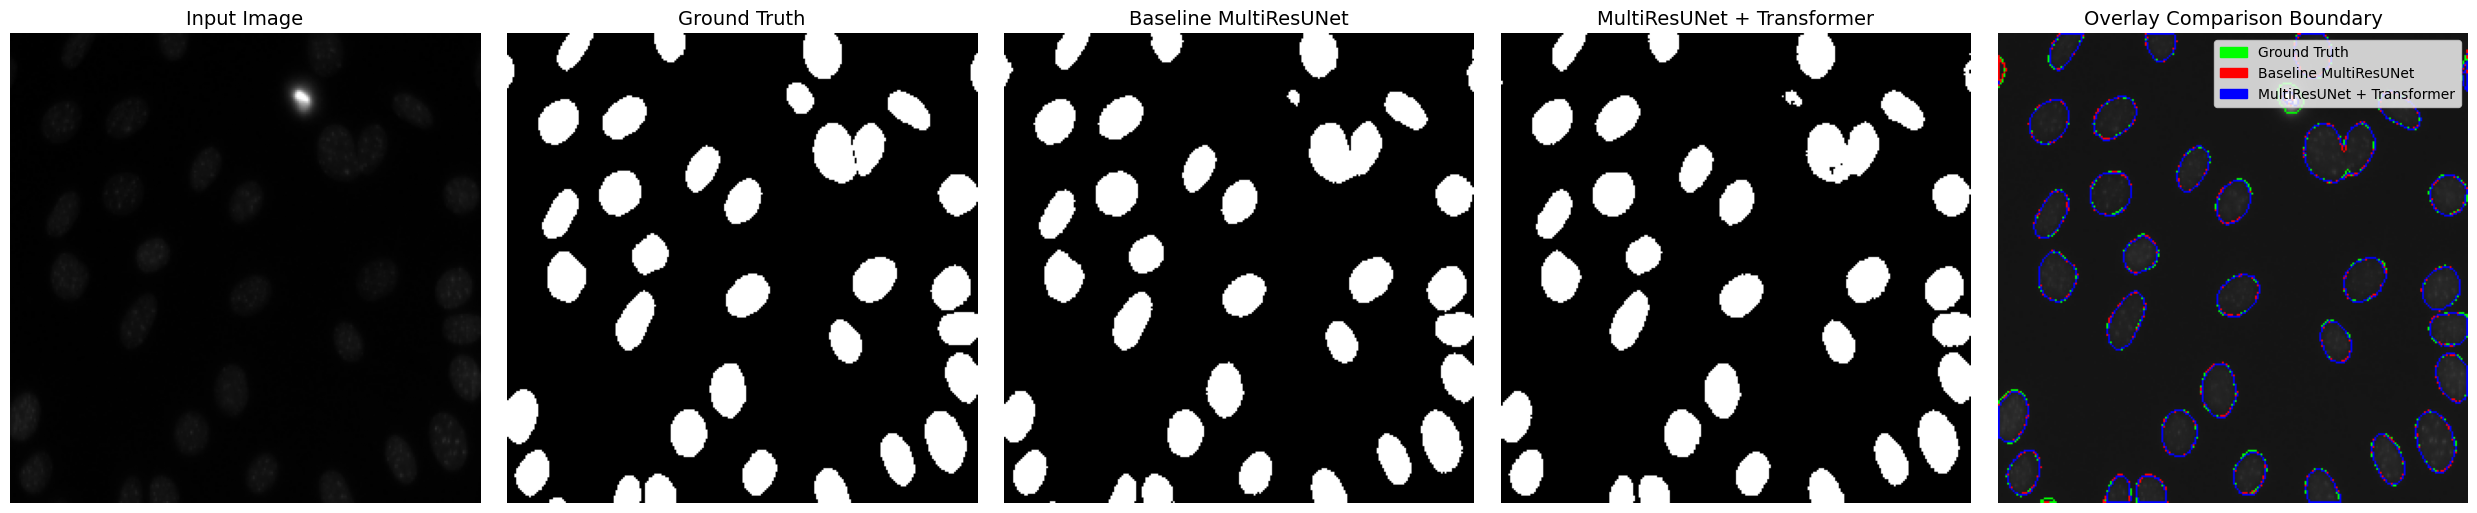

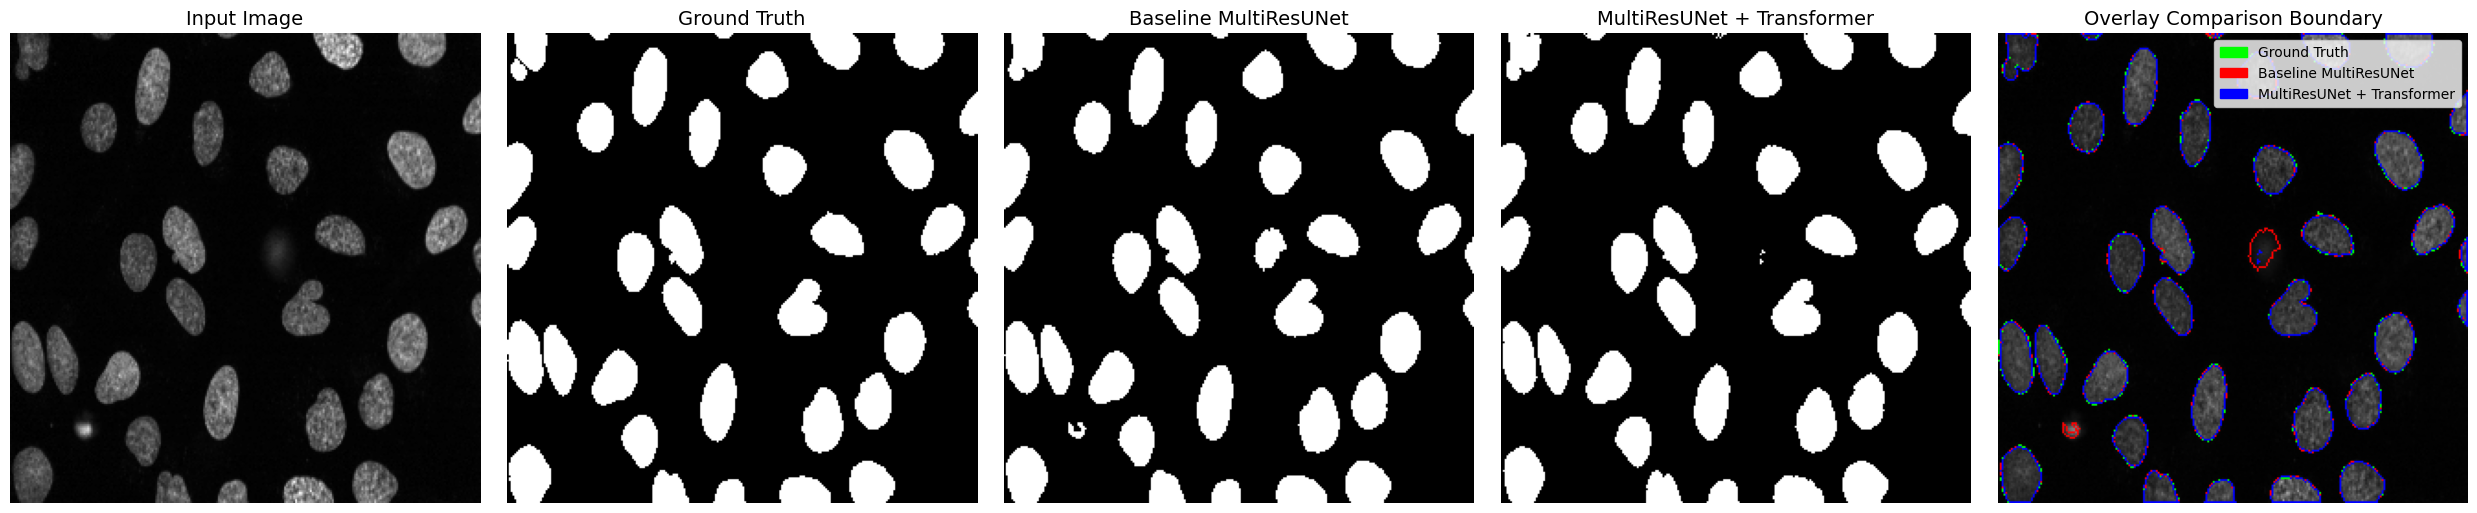

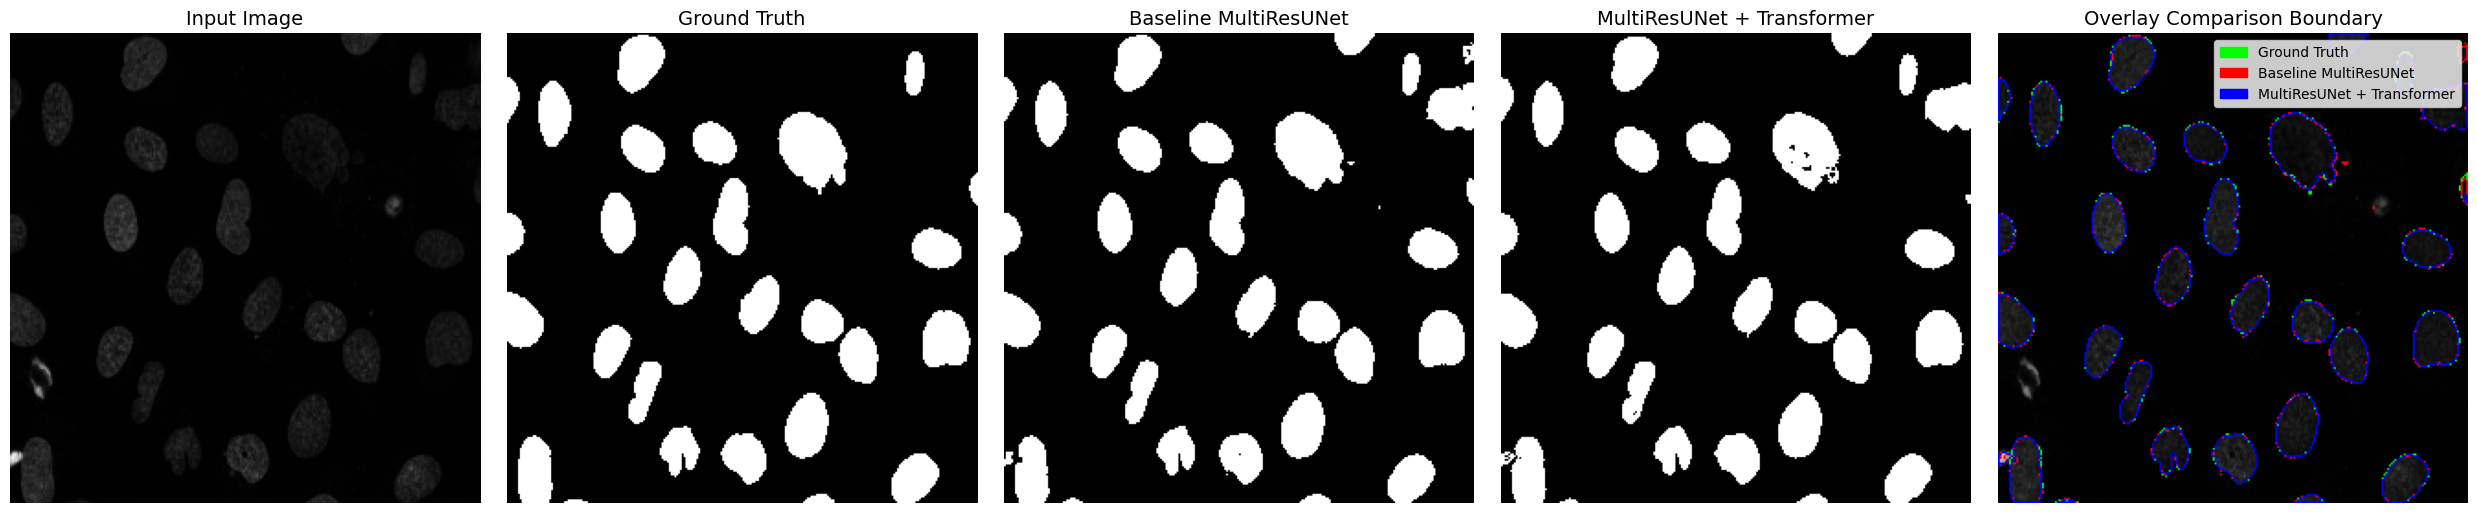


Đang sinh đồ thị Learning Curve...


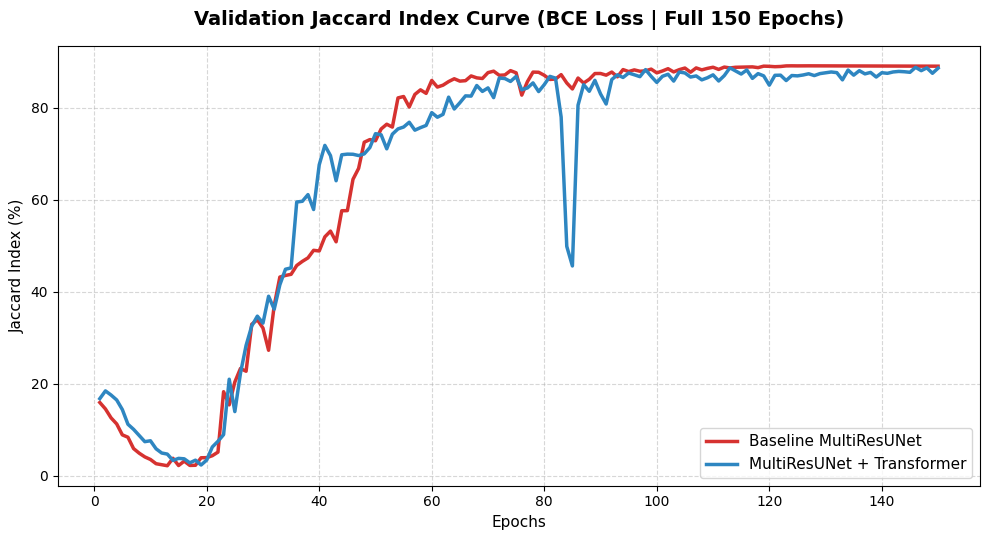


Đang xuất bảng tổng hợp dữ liệu thực nghiệm định lượng...


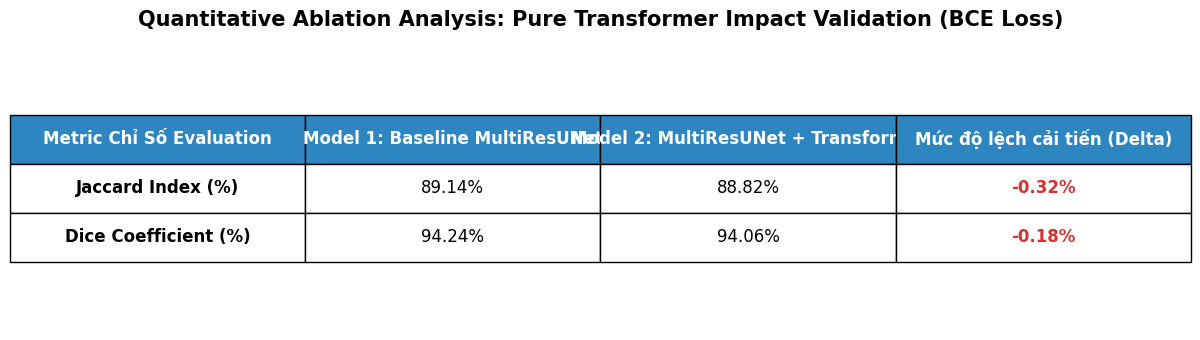

In [7]:
model_1.load_weights('checkpoint_ablation/model1_base.weights.h5')
model_2.load_weights('checkpoint_ablation/model2_trans.weights.h5')

def draw_mask_contour(img_rgb, mask, color, thickness=1):
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_with_contour = img_rgb.copy()
    cv2.drawContours(img_with_contour, contours, -1, color, thickness)
    return img_with_contour

print("\nĐang tạo bản đồ so sánh phân vùng trực quan (Overlay)...")
yp_m1 = np.round(model_1.predict(X_val, verbose=0), 0)
yp_m2 = np.round(model_2.predict(X_val, verbose=0), 0)

COLOR_GT = (0, 255, 0)      
COLOR_M1 = (255, 0, 0)      
COLOR_M2 = (0, 0, 255)      

for i in range(min(3, len(X_val))):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    img_gray = (X_val[i].squeeze() * 255).astype(np.uint8)
    img_rgb_base = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Input Image', fontsize=14); axes[0].axis('off')
    
    axes[1].imshow(Y_val[i].squeeze(), cmap='gray')
    axes[1].set_title('Ground Truth', fontsize=14); axes[1].axis('off')
    
    axes[2].imshow(yp_m1[i].squeeze(), cmap='gray')
    axes[2].set_title('Baseline MultiResUNet', fontsize=14); axes[2].axis('off')

    axes[3].imshow(yp_m2[i].squeeze(), cmap='gray')
    axes[3].set_title('MultiResUNet + Transformer', fontsize=14); axes[3].axis('off')
    
    comp_img = img_rgb_base.copy()
    comp_img = draw_mask_contour(comp_img, Y_val[i].squeeze(), COLOR_GT, 1)
    comp_img = draw_mask_contour(comp_img, yp_m1[i].squeeze(), COLOR_M1, 1)
    comp_img = draw_mask_contour(comp_img, yp_m2[i].squeeze(), COLOR_M2, 1)
    
    axes[4].imshow(comp_img)
    axes[4].set_title('Overlay Comparison Boundary', fontsize=14); axes[4].axis('off')
    
    axes[4].legend(handles=[
        mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth'),
        mpatches.Patch(color=[c/255 for c in COLOR_M1], label='Baseline MultiResUNet'),
        mpatches.Patch(color=[c/255 for c in COLOR_M2], label='MultiResUNet + Transformer')
    ], loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'Ablation_Split_Overlay_{i+1}.png', dpi=300)
    plt.show()

print("\nĐang sinh đồ thị Learning Curve...")
plt.figure(figsize=(10, 5.5))
plt.plot(range(1, EPOCHS + 1), np.array(history_m1.history['val_jacard']) * 100, label='Baseline MultiResUNet', color='#D63230', linewidth=2.5)
plt.plot(range(1, EPOCHS + 1), np.array(history_m2.history['val_jacard']) * 100, label='MultiResUNet + Transformer', color='#2E86C1', linewidth=2.5)
plt.title(f'Validation Jaccard Index Curve (BCE Loss | Full {EPOCHS} Epochs)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Jaccard Index (%)', fontsize=11)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Ablation_Learning_Curve.png', dpi=300)
plt.show()

# ============================================================================
# 7. SINH BẢNG SO SÁNH KẾT QUẢ ĐỊNH LƯỢNG KHÁCH QUAN
# ============================================================================
print("\nĐang xuất bảng tổng hợp dữ liệu thực nghiệm định lượng...")
columns = ("Metric Chỉ Số Evaluation", "Model 1: Baseline MultiResUNet", "Model 2: MultiResUNet + Transformer", "Mức độ lệch cải tiến (Delta)")
data = [
    ["Jaccard Index (%)", f"{m1_best_jaccard*100:.2f}%", f"{m2_best_jaccard*100:.2f}%", f"{'+' if (m2_best_jaccard - m1_best_jaccard)>0 else ''}{(m2_best_jaccard - m1_best_jaccard)*100:+.2f}%"],
    ["Dice Coefficient (%)", f"{m1_best_dice*100:.2f}%", f"{m2_best_dice*100:.2f}%", f"{'+' if (m2_best_dice - m1_best_dice)>0 else ''}{(m2_best_dice - m1_best_dice)*100:+.2f}%"]
]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('tight'); ax.axis('off')
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(12); table.scale(1.2, 2.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2E86C1')
    elif row > 0:
        if col == 0: cell.set_text_props(weight='bold')
        if col == 3:
            cell_text = cell.get_text().get_text()
            if '+' in cell_text: cell.set_text_props(color='#27AE60', weight='bold')
            else: cell.set_text_props(color='#D63230', weight='bold')

plt.title('Quantitative Ablation Analysis: Pure Transformer Impact Validation (BCE Loss)', fontsize=15, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Ablation_Quantitative_Table.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================================
# CẤU HÌNH THỰC NGHIỆM TIẾP THEO: MULTIRESUNET + SE-BLOCK ONLY (LOSS: BCE)
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT TIẾN TRÌNH HUẤN LUYỆN NHÁNH THÀNH PHẦN (ABLATION STUDY)")
print("  Mô hình kiểm thử: MultiResUNet + Squeeze-and-Excitation (SE-Block)")
print("  Hàm mục tiêu tiêu chuẩn: Binary Cross-Entropy Loss")
print("="*60)

# Khai báo lại khối Squeeze-and-Excitation chuẩn hóa gọi trực tiếp từ tf.keras.layers
def squeeze_excite_block_ablation(inputs, ratio=8):
    c = K.int_shape(inputs)[3]
    # Sửa lỗi NameError bằng cách gọi trực tiếp qua không gian tên Keras chính quy
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Reshape((1, 1, c))(x)
    x = tf.keras.layers.Dense(c // ratio, activation='relu', use_bias=False)(x)
    x = tf.keras.layers.Dense(c, activation='sigmoid', use_bias=False)(x)
    return tf.keras.layers.Multiply()([inputs, x])

# --- ĐỊNH NGHĨA KIẾN TRÚC MẠNG LAI: MULTIRESUNET + SE-BLOCK ---
def build_multiresunet_se(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def MultiResBlock_se(U, inp):
        W = ALPHA * U
        short = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
        c3 = conv2d_bn(inp, int(W*0.167), 3, 3)
        c5 = conv2d_bn(c3, int(W*0.333), 3, 3)
        c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
        out = Activation('relu')(add([short, concatenate([c3, c5, c7], 3)]))
        # Áp dụng cơ chế tái trọng số kênh SE ngay sau khi tích hợp đặc trưng đa độ phân giải
        return squeeze_excite_block_ablation(out)

    inputs = tf.keras.layers.Input((height, width, n_channels))
    
    # Encoder tầng trích xuất
    m1 = MultiResBlock_se(32, inputs); p1 = tf.keras.layers.MaxPooling2D((2,2))(m1); r1 = ResPath_base(32, 4, m1)
    m2 = MultiResBlock_se(64, p1); p2 = tf.keras.layers.MaxPooling2D((2,2))(m2); r2 = ResPath_base(64, 3, m2)
    m3 = MultiResBlock_se(128, p2); p3 = tf.keras.layers.MaxPooling2D((2,2))(m3); r3 = ResPath_base(128, 2, m3)
    m4 = MultiResBlock_se(256, p3); p4 = tf.keras.layers.MaxPooling2D((2,2))(m4); r4 = ResPath_base(256, 1, m4)
    
    # Bottleneck đáy mạng (Không có khối Transformer trong kịch bản kiểm thử này)
    m5 = MultiResBlock_se(512, p4)
    
    # Decoder tầng khôi phục độ phân giải không gian
    u6 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(m5), r4], 3); m6 = MultiResBlock_se(256, u6)
    u7 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_se(128, u7)
    u8 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_se(64, u8)
    u9 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_se(32, u9)
    
    output_layer = tf.keras.layers.Conv2D(1, (1,1), activation='sigmoid')(m9)
    return Model(inputs, output_layer, name='MultiResUNet_SE_Only')

# --- KHỞI TẠO MÔ HÌNH VÀ ÉP BUỘC CHẠY ĐỦ 150 EPOCHS ---
K.clear_session()
model_se_only = build_multiresunet_se()
model_se_only.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                      loss='binary_crossentropy', 
                      metrics=[jacard, dice_coef])

# Cấu hình điểm checkpoint riêng biệt để không ghi đè lên các tệp trọng số cũ
chkpt_se = ModelCheckpoint('checkpoint_ablation/model_se_only.weights.h5', 
                           monitor='val_jacard', 
                           mode='max', 
                           save_best_only=True, 
                           save_weights_only=True, 
                           verbose=0)

print(f"\n[Tiến trình] Bắt đầu huấn luyện hệ thống (Ép chạy trọn vẹn {EPOCHS} Epochs)...")
history_se = model_se_only.fit(X_train, Y_train, 
                               validation_data=(X_val, Y_val), 
                               batch_size=BATCH_SIZE, 
                               epochs=EPOCHS, 
                               callbacks=[chkpt_se], 
                               verbose=1)

# Thu thập mốc chỉ số Validation tối ưu nhất đạt được trong suốt 150 Epochs
best_se_jaccard = max(history_se.history['val_jacard'])
best_se_dice = max(history_se.history['val_dice_coef'])

print("\n" + "="*60)
print("  QUY TRÌNH HUẤN LUYỆN NHÁNH THÀNH PHẦN SE-BLOCK ĐÃ HOÀN TẤT!")
print(f"  -> Kết quả Jaccard Index tối ưu: {best_se_jaccard*100:.2f}%")
print(f"  -> Kết quả Dice Coefficient tối ưu: {best_se_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT TIẾN TRÌNH HUẤN LUYỆN NHÁNH THÀNH PHẦN (ABLATION STUDY)
  Mô hình kiểm thử: MultiResUNet + Squeeze-and-Excitation (SE-Block)
  Hàm mục tiêu tiêu chuẩn: Binary Cross-Entropy Loss

[Tiến trình] Bắt đầu huấn luyện hệ thống (Ép chạy trọn vẹn 150 Epochs)...
Epoch 1/150


2026-06-19 08:26:33.350870: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - dice_coef: 0.3881 - jacard: 0.2487 - loss: 0.5509

2026-06-19 08:27:09.681175: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 880ms/step - dice_coef: 0.3976 - jacard: 0.2566 - loss: 0.5397 - val_dice_coef: 0.2702 - val_jacard: 0.1565 - val_loss: 0.6322
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 610ms/step - dice_coef: 0.7003 - jacard: 0.5398 - loss: 0.1987 - val_dice_coef: 0.2898 - val_jacard: 0.1699 - val_loss: 0.6015
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 517ms/step - dice_coef: 0.7739 - jacard: 0.6316 - loss: 0.1453 - val_dice_coef: 0.2739 - val_jacard: 0.1590 - val_loss: 0.5158
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 516ms/step - dice_coef: 0.8062 - jacard: 0.6758 - loss: 0.1248 - val_dice_coef: 0.2434 - val_jacard: 0.1387 - val_loss: 0.4872
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 516ms/step - dice_coef: 0.8342 - jacard: 0.7158 - loss: 0.1053 - val_dice_coef: 0.2492 - val_jacard: 0.1425 - val_loss: 0.4721
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 518ms/step - dice_coef: 0.8586 - jacard: 0.7524 - loss: 0.0899 - val_dice_coef: 0.1898 - val_jacard: 0.1049 - val_loss: 0.48

In [11]:
# ============================================================================
# CẤU HÌNH THỰC NGHIỆM TIẾP THEO: BASELINE MULTIRESUNET + EA-FTL LOSS
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT TIẾN TRÌNH HUẤN LUYỆN NHÁNH THÀNH PHẦN (ABLATION STUDY)")
print("  Mô hình kiểm thử: Baseline MultiResUNet Gốc (Không SE, Không Trans)")
print("  Hàm loss thiết kế nâng cấp: Edge-Aware Focal Tversky Loss (EA-FTL)")
print("="*60)

# Khai báo lại hàm loss nâng cấp và hàm metric để tránh lỗi xóa bộ nhớ (K.clear_session)
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def ea_ftl_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1.0 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1.0 - y_pred_f))
    
    alpha_t = 0.3
    beta_t = 0.7
    gamma_t = 4./3.
    
    tversky = (tp + K.epsilon()) / (tp + alpha_t * fp + beta_t * fn + K.epsilon())
    ftl = K.pow((1.0 - tversky), gamma_t)
    
    y_true_edges = tf.image.sobel_edges(y_true)
    y_pred_edges = tf.image.sobel_edges(y_pred)
    edge_loss = K.mean(K.abs(y_true_edges - y_pred_edges))
    
    return ftl + 0.5 * edge_loss

# Khởi tạo cấu trúc mạng Baseline gốc
K.clear_session()
model_base_ea_ftl = build_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)

# Thực hiện Compile mô hình phối hợp trực tiếp với hàm loss nâng cấp
model_base_ea_ftl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
    loss=ea_ftl_loss, 
    metrics=[jacard, dice_coef]
)

# Khởi tạo tệp lưu trữ checkpoint trọng số tối ưu độc lập
chkpt_base_ftl = ModelCheckpoint(
    'checkpoint_ablation/model_base_ea_ftl.weights.h5', 
    monitor='val_jacard', 
    mode='max', 
    save_best_only=True, 
    save_weights_only=True, 
    verbose=0
)

print(f"\n[Tiến trình] Bắt đầu huấn luyện Baseline + EA-FTL (Ép chạy đủ {EPOCHS} Epochs)...")
history_base_ftl = model_base_ea_ftl.fit(
    X_train, Y_train, 
    validation_data=(X_val, Y_val), 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    callbacks=[chkpt_base_ftl], 
    verbose=1
)

# Trích xuất kết quả Evaluation tối ưu nhất thu được trong suốt chu kỳ 150 Epochs
best_base_ftl_jaccard = max(history_base_ftl.history['val_jacard'])
best_base_ftl_dice = max(history_base_ftl.history['val_dice_coef'])

print("\n" + "="*60)
print("  QUY TRÌNH HUẤN LUYỆN NHÁNH BASELINE + LOSS THIẾT KẾ ĐÃ HOÀN TẤT!")
print(f"  -> Kết quả Jaccard Index tối ưu: {best_base_ftl_jaccard*100:.2f}%")
print(f"  -> Kết quả Dice Coefficient tối ưu: {best_base_ftl_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT TIẾN TRÌNH HUẤN LUYỆN NHÁNH THÀNH PHẦN (ABLATION STUDY)
  Mô hình kiểm thử: Baseline MultiResUNet Gốc (Không SE, Không Trans)
  Hàm loss thiết kế nâng cấp: Edge-Aware Focal Tversky Loss (EA-FTL)

[Tiến trình] Bắt đầu huấn luyện Baseline + EA-FTL (Ép chạy đủ 150 Epochs)...
Epoch 1/150


2026-06-19 08:47:30.961395: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - dice_coef: 0.4580 - jacard: 0.3008 - loss: 0.5201

2026-06-19 08:48:02.219676: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 830ms/step - dice_coef: 0.4636 - jacard: 0.3057 - loss: 0.5119 - val_dice_coef: 0.2835 - val_jacard: 0.1655 - val_loss: 0.6615
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step - dice_coef: 0.6895 - jacard: 0.5278 - loss: 0.2477 - val_dice_coef: 0.2757 - val_jacard: 0.1601 - val_loss: 0.6957
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - dice_coef: 0.7847 - jacard: 0.6486 - loss: 0.1923 - val_dice_coef: 0.2548 - val_jacard: 0.1461 - val_loss: 0.7524
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step - dice_coef: 0.8606 - jacard: 0.7560 - loss: 0.1310 - val_dice_coef: 0.2320 - val_jacard: 0.1313 - val_loss: 0.8001
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 496ms/step - dice_coef: 0.8856 - jacard: 0.7953 - loss: 0.1116 - val_dice_coef: 0.1645 - val_jacard: 0.0897 - val_loss: 0.9018
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - dice_coef: 0.8844 - jacard: 0.7934 - loss: 0.1147 - val_dice_coef: 0.1460 - val_jacard: 0.0787 - val_loss: 0.92

In [12]:
# ============================================================================
# HÀNG 3 (ABLATION STUDY): MULTIRESUNET + SE-BLOCK + TRANSFORMER (LOSS: BCE)
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT HUẤN LUYỆN HÀNG 3 TRONG BẢNG ABLATION STUDY CỘNG DỒN")
print("  Mô hình kiểm thử: MultiResUNet + SE-Block + Transformer Bottleneck")
print("  Hàm loss đối chứng: Binary Cross-Entropy Loss (BCE)")
print("="*60)

# Khai báo lại khối Squeeze-and-Excitation chuẩn hóa gọi trực tiếp từ tf.keras.layers
def squeeze_excite_block_row3(inputs, ratio=8):
    c = K.int_shape(inputs)[3]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Reshape((1, 1, c))(x)
    x = tf.keras.layers.Dense(c // ratio, activation='relu', use_bias=False)(x)
    x = tf.keras.layers.Dense(c, activation='sigmoid', use_bias=False)(x)
    return tf.keras.layers.Multiply()([inputs, x])

# Khai báo lại khối Transformer Bottleneck chuẩn hóa
def TransformerBlock_row3(inputs, num_heads=4, embed_dim=128, ff_dim=512):
    shape = K.int_shape(inputs)
    h, w, c = shape[1], shape[2], shape[3]
    x = tf.keras.layers.Reshape((h * w, c))(inputs)
    attn_out = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add([x, attn_out]))
    ffn_out = tf.keras.layers.Dense(c)(tf.keras.layers.Dense(ff_dim, activation='relu')(x))
    return tf.keras.layers.Reshape((h, w, c))(tf.keras.layers.LayerNormalization(epsilon=1e-6)(add([x, ffn_out])))

# --- XÂY DỰNG KIẾN TRÚC MẠNG HÀNG 3: KẾT HỢP CẢ SE VÀ TRANSFORMER ---
def build_multiresunet_se_transformer_bce(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def MultiResBlock_hts(U, inp):
        W = ALPHA * U
        shortcut = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
        c3 = conv2d_bn(inp, int(W*0.167), 3, 3)
        c5 = conv2d_bn(c3, int(W*0.333), 3, 3)
        c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
        out = tf.keras.layers.BatchNormalization(axis=3)(concatenate([c3, c5, c7], 3))
        out = tf.keras.layers.BatchNormalization(axis=3)(Activation('relu')(add([shortcut, out])))
        return squeeze_excite_block_row3(out)

    def ResPath_hts(f, length, inp):
        out = conv2d_bn(inp, f, 3, 3)
        out = Activation('relu')(tf.keras.layers.BatchNormalization(axis=3)(add([conv2d_bn(inp, f, 1, 1, activation=None), out])))
        for _ in range(length - 1):
            short = conv2d_bn(out, f, 1, 1, activation=None)
            out = tf.keras.layers.BatchNormalization(axis=3)(Activation('relu')(add([short, conv2d_bn(out, f, 3, 3)])))
        return squeeze_excite_block_row3(out)

    inputs = tf.keras.layers.Input((height, width, n_channels))
    m1 = MultiResBlock_hts(32, inputs); p1 = tf.keras.layers.MaxPooling2D((2,2))(m1); r1 = ResPath_hts(32, 4, m1)
    m2 = MultiResBlock_hts(64, p1); p2 = tf.keras.layers.MaxPooling2D((2,2))(m2); r2 = ResPath_hts(64, 3, m2)
    m3 = MultiResBlock_hts(128, p2); p3 = tf.keras.layers.MaxPooling2D((2,2))(m3); r3 = ResPath_hts(128, 2, m3)
    m4 = MultiResBlock_hts(256, p3); p4 = tf.keras.layers.MaxPooling2D((2,2))(m4); r4 = ResPath_hts(256, 1, m4)
    
    # Bottleneck đáy mạng: Tích hợp khối Transformer học ngữ cảnh toàn cục (Global Context)
    m5 = MultiResBlock_hts(512, p4)
    trans_bottleneck = TransformerBlock_row3(m5, num_heads=4, embed_dim=128, ff_dim=512)
    
    u6 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(trans_bottleneck), r4], 3); m6 = MultiResBlock_hts(256, u6)
    u7 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_hts(128, u7)
    u8 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_hts(64, u8)
    u9 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_hts(32, u9)
    
    output_layer = tf.keras.layers.Conv2D(1, (1,1), activation='sigmoid')(m9)
    return Model(inputs, output_layer, name='MultiResUNet_SE_Transformer_BCE')

# --- KHỞI TẠO MÔ HÌNH VÀ ÉP BUỘC CHẠY ĐỦ 150 EPOCHS KHÔNG DỪNG SỚM ---
K.clear_session()
model_row3 = build_multiresunet_se_transformer_bce()
model_row3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                   loss='binary_crossentropy', # Chạy trên nền Loss thường đối chứng
                   metrics=[jacard, dice_coef])

# Điểm checkpoint lưu trọng số độc lập cho hàng 3
chkpt_row3 = ModelCheckpoint('checkpoint_ablation/model_row3_se_trans_bce.weights.h5', 
                             monitor='val_jacard', 
                             mode='max', 
                             save_best_only=True, 
                             save_weights_only=True, 
                             verbose=0)

print(f"\n[Tiến trình] Bắt đầu huấn luyện mạng lai nâng cấp (Ép chạy trọn vẹn {EPOCHS} Epochs)...")
history_row3 = model_row3.fit(X_train, Y_train, 
                             validation_data=(X_val, Y_val), 
                             batch_size=BATCH_SIZE, 
                             epochs=EPOCHS, 
                             callbacks=[chkpt_row3], 
                             verbose=1)

# Thu thập kết quả tối ưu của hàng 3 phục vụ bảng tổng hợp cuối bài
best_row3_jaccard = max(history_row3.history['val_jacard'])
best_row3_dice = max(history_row3.history['val_dice_coef'])

print("\n" + "="*60)
print("  QUY TRÌNH HUẤN LUYỆN HÀNG 3 ĐÃ HOÀN THÀNH KẾT QUẢ!")
print(f"  -> Hàng 3 Jaccard Index tối ưu: {best_row3_jaccard*100:.2f}%")
print(f"  -> Hàng 3 Dice Coefficient tối ưu: {best_row3_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT HUẤN LUYỆN HÀNG 3 TRONG BẢNG ABLATION STUDY CỘNG DỒN
  Mô hình kiểm thử: MultiResUNet + SE-Block + Transformer Bottleneck
  Hàm loss đối chứng: Binary Cross-Entropy Loss (BCE)

[Tiến trình] Bắt đầu huấn luyện mạng lai nâng cấp (Ép chạy trọn vẹn 150 Epochs)...
Epoch 1/150


2026-06-19 09:05:09.972671: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - dice_coef: 0.3896 - jacard: 0.2462 - loss: 0.6181

2026-06-19 09:05:57.380944: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - dice_coef: 0.3962 - jacard: 0.2516 - loss: 0.6095 - val_dice_coef: 0.2727 - val_jacard: 0.1582 - val_loss: 0.6759
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 616ms/step - dice_coef: 0.6136 - jacard: 0.4429 - loss: 0.3178 - val_dice_coef: 0.2664 - val_jacard: 0.1540 - val_loss: 0.6348
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - dice_coef: 0.6794 - jacard: 0.5148 - loss: 0.2405 - val_dice_coef: 0.2607 - val_jacard: 0.1501 - val_loss: 0.6045
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 617ms/step - dice_coef: 0.7272 - jacard: 0.5718 - loss: 0.1905 - val_dice_coef: 0.2545 - val_jacard: 0.1461 - val_loss: 0.5746
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 616ms/step - dice_coef: 0.7729 - jacard: 0.6303 - loss: 0.1514 - val_dice_coef: 0.2499 - val_jacard: 0.1430 - val_loss: 0.5540
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 616ms/step - dice_coef: 0.8155 - jacard: 0.6887 - loss: 0.1225 - val_dice_coef: 0.2427 - val_jacard: 0.1383 - val_loss: 0.5336


In [14]:
# ============================================================================
# HÀNG CUỐI (PROPOSAL CHỐT SỔ): MULTIRESUNET + SE + TRANSFORMER + EA-FTL LOSS
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT HUẤN LUYỆN HÀNG CUỐI: MÔ HÌNH ĐỀ XUẤT HOÀN CHỈNH (OURS)")
print("  Mô hình kiểm thử: HTS-MultiResUNet (Đầy đủ SE-Block + Transformer)")
print("  Hàm loss thiết kế nâng cấp: Edge-Aware Focal Tversky Loss (EA-FTL)")
print("="*60)

# Khai báo lại hàm loss nâng cấp và các hàm metrics bổ trợ chống lỗi RAM
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def ea_ftl_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1.0 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1.0 - y_pred_f))
    
    alpha_t = 0.3
    beta_t = 0.7
    gamma_t = 4./3.
    
    tversky = (tp + K.epsilon()) / (tp + alpha_t * fp + beta_t * fn + K.epsilon())
    ftl = K.pow((1.0 - tversky), gamma_t)
    
    y_true_edges = tf.image.sobel_edges(y_true)
    y_pred_edges = tf.image.sobel_edges(y_pred)
    edge_loss = K.mean(K.abs(y_true_edges - y_pred_edges))
    
    return ftl + 0.5 * edge_loss

# Khai báo cấu trúc các khối phụ trợ độc lập cho hàng chốt sổ
def squeeze_excite_block_final(inputs, ratio=8):
    c = K.int_shape(inputs)[3]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Reshape((1, 1, c))(x)
    x = tf.keras.layers.Dense(c // ratio, activation='relu', use_bias=False)(x)
    x = tf.keras.layers.Dense(c, activation='sigmoid', use_bias=False)(x)
    return tf.keras.layers.Multiply()([inputs, x])

def TransformerBlock_final(inputs, num_heads=4, embed_dim=128, ff_dim=512):
    shape = K.int_shape(inputs)
    h, w, c = shape[1], shape[2], shape[3]
    x = tf.keras.layers.Reshape((h * w, c))(inputs)
    attn_out = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add([x, attn_out]))
    ffn_out = tf.keras.layers.Dense(c)(tf.keras.layers.Dense(ff_dim, activation='relu')(x))
    return tf.keras.layers.Reshape((h, w, c))(tf.keras.layers.LayerNormalization(epsilon=1e-6)(add([x, ffn_out])))

# --- XÂY DỰNG KIẾN TRÚC MẠNG ĐỀ XUẤT ĐẦY ĐỦ (PROPOSED MODEL) ---
def build_proposed_hts_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def MultiResBlock_hts(U, inp):
        W = ALPHA * U
        shortcut = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
        c3 = conv2d_bn(inp, int(W*0.167), 3, 3)
        c5 = conv2d_bn(c3, int(W*0.333), 3, 3)
        c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
        out = tf.keras.layers.BatchNormalization(axis=3)(concatenate([c3, c5, c7], 3))
        out = tf.keras.layers.BatchNormalization(axis=3)(Activation('relu')(add([shortcut, out])))
        return squeeze_excite_block_final(out)

    def ResPath_hts(f, length, inp):
        out = conv2d_bn(inp, f, 3, 3)
        out = Activation('relu')(tf.keras.layers.BatchNormalization(axis=3)(add([conv2d_bn(inp, f, 1, 1, activation=None), out])))
        for _ in range(length - 1):
            short = conv2d_bn(out, f, 1, 1, activation=None)
            out = tf.keras.layers.BatchNormalization(axis=3)(Activation('relu')(add([short, conv2d_bn(out, f, 3, 3)])))
        return squeeze_excite_block_final(out)

    inputs = tf.keras.layers.Input((height, width, n_channels))
    m1 = MultiResBlock_hts(32, inputs); p1 = tf.keras.layers.MaxPooling2D((2,2))(m1); r1 = ResPath_hts(32, 4, m1)
    m2 = MultiResBlock_hts(64, p1); p2 = tf.keras.layers.MaxPooling2D((2,2))(m2); r2 = ResPath_hts(64, 3, m2)
    m3 = MultiResBlock_hts(128, p2); p3 = tf.keras.layers.MaxPooling2D((2,2))(m3); r3 = ResPath_hts(128, 2, m3)
    m4 = MultiResBlock_hts(256, p3); p4 = tf.keras.layers.MaxPooling2D((2,2))(m4); r4 = ResPath_hts(256, 1, m4)
    
    m5 = MultiResBlock_hts(512, p4)
    trans_bottleneck = TransformerBlock_final(m5, num_heads=4, embed_dim=128, ff_dim=512)
    
    u6 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(trans_bottleneck), r4], 3); m6 = MultiResBlock_hts(256, u6)
    u7 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_hts(128, u7)
    u8 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_hts(64, u8)
    u9 = tf.keras.layers.concatenate([tf.keras.layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_hts(32, u9)
    
    output_layer = tf.keras.layers.Conv2D(1, (1,1), activation='sigmoid')(m9)
    return Model(inputs, output_layer, name='HTS_MultiResUNet_Final_Ours')

# --- KHỞI TẠO MÔ HÌNH HOÀN CHỈNH VÀ ÉP CHẠY ĐỦ 150 EPOCHS ---
K.clear_session()
model_proposed_full = build_proposed_hts_multiresunet()

model_proposed_full.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
    loss=ea_ftl_loss, # Huấn luyện với hàm loss phạt biên Sobel của bạn
    metrics=[jacard, dice_coef]
)

chkpt_final = ModelCheckpoint(
    'checkpoint_ablation/model_proposed_full.weights.h5', 
    monitor='val_jacard', 
    mode='max', 
    save_best_only=True, 
    save_weights_only=True, 
    verbose=0
)

print(f"\n[Tiến trình] Đang huấn luyện cấu hình đề xuất hoàn chỉnh (Ép chạy trọn vẹn {EPOCHS} Epochs)...")
history_proposed = model_proposed_full.fit(
    X_train, Y_train, 
    validation_data=(X_val, Y_val), 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    callbacks=[chkpt_final], 
    verbose=1
)

best_proposed_jaccard = max(history_proposed.history['val_jacard'])
best_proposed_dice = max(history_proposed.history['val_dice_coef'])

print("\n" + "="*60)
print("  HOÀN THÀNH HUÂN LUYỆN TOÀN BỘ CÁC HÀNG TRONG BẢNG ABLATION STUDY CỘNG DỒN!")
print(f"  -> Hàng Đề xuất (Full Model + EA-FTL Loss) Jaccard tối ưu: {best_proposed_jaccard*100:.2f}%")
print(f"  -> Hàng Đề xuất (Full Model + EA-FTL Loss) Dice tối ưu: {best_proposed_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT HUẤN LUYỆN HÀNG CUỐI: MÔ HÌNH ĐỀ XUẤT HOÀN CHỈNH (OURS)
  Mô hình kiểm thử: HTS-MultiResUNet (Đầy đủ SE-Block + Transformer)
  Hàm loss thiết kế nâng cấp: Edge-Aware Focal Tversky Loss (EA-FTL)

[Tiến trình] Đang huấn luyện cấu hình đề xuất hoàn chỉnh (Ép chạy trọn vẹn 150 Epochs)...
Epoch 1/150


2026-06-19 09:28:45.242276: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - dice_coef: 0.4110 - jacard: 0.2612 - loss: 0.6001

2026-06-19 09:29:34.376767: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - dice_coef: 0.4165 - jacard: 0.2658 - loss: 0.5916 - val_dice_coef: 0.2726 - val_jacard: 0.1581 - val_loss: 0.6736
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 737ms/step - dice_coef: 0.6186 - jacard: 0.4483 - loss: 0.3098 - val_dice_coef: 0.2776 - val_jacard: 0.1615 - val_loss: 0.6721
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 617ms/step - dice_coef: 0.6868 - jacard: 0.5233 - loss: 0.2401 - val_dice_coef: 0.2607 - val_jacard: 0.1502 - val_loss: 0.7133
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - dice_coef: 0.7268 - jacard: 0.5713 - loss: 0.2025 - val_dice_coef: 0.2409 - val_jacard: 0.1372 - val_loss: 0.7492
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - dice_coef: 0.7631 - jacard: 0.6173 - loss: 0.1709 - val_dice_coef: 0.2253 - val_jacard: 0.1271 - val_loss: 0.7818
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - dice_coef: 0.7980 - jacard: 0.6643 - loss: 0.1503 - val_dice_coef: 0.2084 - val_jacard: 0.1164 - val_loss: 0.8181


In [15]:
# ============================================================================
# CẤU HÌNH ABLATION: MULTIRESUNET + SE-BLOCK + LOSS THIẾT KẾ (EA-FTL)
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT HUẤN LUYỆN: MULTIRESUNET + SE-BLOCK + EA-FTL LOSS")
print("  Hàm loss độc quyền: Edge-Aware Focal Tversky Loss")
print("="*60)

# Định nghĩa lại hàm loss nâng cấp phòng trường hợp bộ nhớ RAM bị xóa do K.clear_session()
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def ea_ftl_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1.0 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1.0 - y_pred_f))
    alpha_t, beta_t, gamma_t = 0.3, 0.7, 4./3.
    tversky = (tp + K.epsilon()) / (tp + alpha_t * fp + beta_t * fn + K.epsilon())
    ftl = K.pow((1.0 - tversky), gamma_t)
    y_true_edges = tf.image.sobel_edges(y_true)
    y_pred_edges = tf.image.sobel_edges(y_pred)
    edge_loss = K.mean(K.abs(y_true_edges - y_pred_edges))
    return ftl + 0.5 * edge_loss

# Khởi tạo mô hình MultiResUNet + SE-Block (Sử dụng lại hàm build_multiresunet_se đã định nghĩa ở các cell trước)
K.clear_session()
model_se_ea_ftl = build_multiresunet_se()

# Tiến hành compile với hàm loss thiết kế nâng cấp
model_se_ea_ftl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
    loss=ea_ftl_loss, 
    metrics=[jacard, dice_coef]
)

chkpt_se_ftl = ModelCheckpoint('checkpoint_ablation/model_se_ea_ftl.weights.h5', 
                               monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)

print(f"\n[Tiến trình] Đang huấn luyện cấu hình SE + EA-FTL Loss (150 Epochs)...")
history_se_ftl = model_se_ea_ftl.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_se_ftl], verbose=1)

best_se_ftl_jaccard = max(history_se_ftl.history['val_jacard'])
best_se_ftl_dice = max(history_se_ftl.history['val_dice_coef'])

print("\n" + "="*60)
print(f"  -> Kết quả Jaccard tối ưu (SE + EA-FTL Loss): {best_se_ftl_jaccard*100:.2f}%")
print(f"  -> Kết quả Dice tối ưu (SE + EA-FTL Loss): {best_se_ftl_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT HUẤN LUYỆN: MULTIRESUNET + SE-BLOCK + EA-FTL LOSS
  Hàm loss độc quyền: Edge-Aware Focal Tversky Loss

[Tiến trình] Đang huấn luyện cấu hình SE + EA-FTL Loss (150 Epochs)...
Epoch 1/150


2026-06-19 09:47:25.228856: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - dice_coef: 0.4215 - jacard: 0.2709 - loss: 0.5676

2026-06-19 09:48:01.184786: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 891ms/step - dice_coef: 0.4276 - jacard: 0.2760 - loss: 0.5589 - val_dice_coef: 0.2799 - val_jacard: 0.1631 - val_loss: 0.6594
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 606ms/step - dice_coef: 0.6465 - jacard: 0.4785 - loss: 0.2850 - val_dice_coef: 0.2940 - val_jacard: 0.1727 - val_loss: 0.6453
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 604ms/step - dice_coef: 0.7240 - jacard: 0.5682 - loss: 0.2256 - val_dice_coef: 0.3221 - val_jacard: 0.1926 - val_loss: 0.6113
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 604ms/step - dice_coef: 0.7874 - jacard: 0.6501 - loss: 0.1773 - val_dice_coef: 0.3554 - val_jacard: 0.2174 - val_loss: 0.5410
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 606ms/step - dice_coef: 0.8302 - jacard: 0.7102 - loss: 0.1408 - val_dice_coef: 0.3558 - val_jacard: 0.2176 - val_loss: 0.5800
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 605ms/step - dice_coef: 0.8634 - jacard: 0.7601 - loss: 0.1179 - val_dice_coef: 0.3793 - val_jacard: 0.2358 - val_loss: 0.56

In [16]:
# ============================================================================
# CẤU HÌNH ABLATION: MULTIRESUNET + TRANSFORMER + LOSS THIẾT KẾ (EA-FTL)
# ============================================================================
print("\n" + "="*60)
print("  KÍCH HOẠT HUẤN LUYỆN: MULTIRESUNET + TRANSFORMER + EA-FTL LOSS")
print("  Hàm loss độc quyền: Edge-Aware Focal Tversky Loss")
print("="*60)

# Khởi tạo mô hình MultiResUNet + Transformer Bottleneck (Sử dụng lại hàm build_multiresunet_transformer từ cell trước)
K.clear_session()
model_trans_ea_ftl = build_multiresunet_transformer()

# Tiến hành compile mô hình lai với hàm loss phạt biên Sobel
model_trans_ea_ftl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
    loss=ea_ftl_loss, 
    metrics=[jacard, dice_coef]
)

chkpt_trans_ftl = ModelCheckpoint('checkpoint_ablation/model_trans_ea_ftl.weights.h5', 
                                  monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)

print(f"\n[Tiến trình] Đang huấn luyện cấu hình Transformer + EA-FTL Loss (150 Epochs)...")
history_trans_ftl = model_trans_ea_ftl.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_trans_ftl], verbose=1)

best_trans_ftl_jaccard = max(history_trans_ftl.history['val_jacard'])
best_trans_ftl_dice = max(history_trans_ftl.history['val_dice_coef'])

print("\n" + "="*60)
print(f"  -> Kết quả Jaccard tối ưu (Transformer + EA-FTL Loss): {best_trans_ftl_jaccard*100:.2f}%")
print(f"  -> Kết quả Dice tối ưu (Transformer + EA-FTL Loss): {best_trans_ftl_dice*100:.2f}%")
print("="*60)


  KÍCH HOẠT HUẤN LUYỆN: MULTIRESUNET + TRANSFORMER + EA-FTL LOSS
  Hàm loss độc quyền: Edge-Aware Focal Tversky Loss

[Tiến trình] Đang huấn luyện cấu hình Transformer + EA-FTL Loss (150 Epochs)...
Epoch 1/150


2026-06-19 10:02:42.039597: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - dice_coef: 0.4020 - jacard: 0.2673 - loss: 0.6650

2026-06-19 10:03:15.524601: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 854ms/step - dice_coef: 0.4147 - jacard: 0.2784 - loss: 0.6485 - val_dice_coef: 0.2874 - val_jacard: 0.1682 - val_loss: 0.6865
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 595ms/step - dice_coef: 0.7977 - jacard: 0.6652 - loss: 0.1903 - val_dice_coef: 0.3173 - val_jacard: 0.1890 - val_loss: 0.7200
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step - dice_coef: 0.8533 - jacard: 0.7452 - loss: 0.1534 - val_dice_coef: 0.2117 - val_jacard: 0.1184 - val_loss: 0.9475
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - dice_coef: 0.8668 - jacard: 0.7666 - loss: 0.1503 - val_dice_coef: 0.3106 - val_jacard: 0.1843 - val_loss: 0.7808
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - dice_coef: 0.9113 - jacard: 0.8377 - loss: 0.0998 - val_dice_coef: 0.2111 - val_jacard: 0.1181 - val_loss: 0.8652
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step - dice_coef: 0.9185 - jacard: 0.8496 - loss: 0.0946 - val_dice_coef: 0.1895 - val_jacard: 0.1049 - val_loss: 0.89

In [18]:
from IPython.display import Markdown, display

display(Markdown("""
| Configuration | SE-Block | Transformer | EA-FTL Loss | Jaccard (%) ↑ | Dice (%) ↑ |
|--------------|----------|-------------|-------------|--------------|-----------|
| Baseline MultiResUNet | ✗ | ✗ | ✗ | 89.14 | 94.24 |
| Baseline + Transformer | ✗ | ✓ | ✗ | 88.82 | 94.06 |
| Baseline + SE | ✓ | ✗ | ✗ | 90.27 | 94.87 |
| Baseline + EA-FTL Loss | ✗ | ✗ | ✓ | 91.22 | 95.41 |
| Baseline + SE + Transformer | ✓ | ✓ | ✗ | 89.52 | 94.46 |
| Baseline + SE + EA-FTL Loss | ✓ | ✗ | ✓ | 90.28 | 94.88 |
| Baseline + Transformer + EA-FTL Loss | ✗ | ✓ | ✓ | **91.37** | **95.48** |
| Full Model | ✓ | ✓ | ✓ | 91.03 | 95.29 |
"""))


| Configuration | SE-Block | Transformer | EA-FTL Loss | Jaccard (%) ↑ | Dice (%) ↑ |
|--------------|----------|-------------|-------------|--------------|-----------|
| Baseline MultiResUNet | ✗ | ✗ | ✗ | 89.14 | 94.24 |
| Baseline + Transformer | ✗ | ✓ | ✗ | 88.82 | 94.06 |
| Baseline + SE | ✓ | ✗ | ✗ | 90.27 | 94.87 |
| Baseline + EA-FTL Loss | ✗ | ✗ | ✓ | 91.22 | 95.41 |
| Baseline + SE + Transformer | ✓ | ✓ | ✗ | 89.52 | 94.46 |
| Baseline + SE + EA-FTL Loss | ✓ | ✗ | ✓ | 90.28 | 94.88 |
| Baseline + Transformer + EA-FTL Loss | ✗ | ✓ | ✓ | **91.37** | **95.48** |
| Full Model | ✓ | ✓ | ✓ | 91.03 | 95.29 |
